In [1]:
import pandas as pd

# machine_code | action_type_name | system_name | count
df = pd.read_csv('count_action_types.csv')
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'count_action_types.csv'

In [ ]:
# plotly tree map : hierarchical plot with machine_code as root, then system_name and action_type_name as branches, and count as values
import plotly.express as px
fig = px.treemap(
    df,
    path=[px.Constant("Fleet"), "machine_code", "system_name", "action_type_name"],
    values="count",
    color="system_name",
    color_discrete_sequence=[
        "#7fc8a9", "#f2c14e", "#e76f51", "#6c91c2", "#c084cc", "#9ccf5a"
    ]
)

fig.update_traces(
    textinfo="label+value+percent parent",
    marker=dict(line=dict(color="white", width=2)),
    root_color="whitesmoke"
)

fig.update_layout(
    paper_bgcolor="white",
    plot_bgcolor="white",
    margin=dict(t=30, l=10, r=10, b=10),
    uniformtext=dict(minsize=10, mode="hide")
)

fig.show()

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_parquet("C:/Users/patri/Coddi/Proyectos/telemetry_dashboard/notebooks/query_pato.parquet")

df.head()

,machine_code,start_time,end_time,system,action_type_name,clean_text,component_name,is_planned_pm,criticidad
0,T_09,2024-12-05T05:00:00-00:00,2024-12-05T05:30:00-00:00,Tren de Fuerza,Reemplazo,OT-551824: cambio de filtro de diferencial y c...,Diferencial,0,3
1,T_09,2024-12-05T05:00:00-00:00,2024-12-05T05:30:00-00:00,Tren de Fuerza,Ajuste,OT-551824: cambio de filtro de diferencial y c...,Diferencial,0,2
2,T_09,2024-12-17T01:05:00-00:00,2024-12-17T02:36:00-00:00,Tren de Fuerza,Relleno,OT 553170: Cambio de aceite en masa derecha. S...,Mando Final Derecho,0,1
3,T_09,2024-12-17T01:05:00-00:00,2024-12-17T02:36:00-00:00,Tren de Fuerza,Ajuste,OT 553170: Cambio de aceite en masa derecha. S...,Mando Final Derecho,0,2
4,T_09,2024-12-19T23:45:00Z,2024-12-21T02:00:00Z,Tren de Fuerza,Ajuste,Se traslada el equipo a taller para pre-PM y l...,Sensor de Velocidad de Transmisión,1,2


In [ ]:
df.system.value_counts()

system
Sistema de Motor        951
Tren de Fuerza          773
Sistema de Dirección    304
Sistema de Frenado      218
Name: count, dtype: int64

In [ ]:
df_aux = df[(df.system == 'Tren de Fuerza') 
            & (df.component_name.str.contains('Transmisión'))
            & (df.action_type_name == 'Reemplazo')
            ].copy()

df_aux.head()

,machine_code,start_time,end_time,system,action_type_name,clean_text,component_name,is_planned_pm,criticidad
32,T_09,2025-03-04T09:15:00-03:00,2025-03-07T23:03:00-03:00,Tren de Fuerza,Reemplazo,Equipo fuera de servicio por problemas de tran...,Cámara de Succión Transmisión,1,3
38,T_09,2025-03-04T09:15:00-03:00,2025-03-07T23:03:00-03:00,Tren de Fuerza,Reemplazo,Equipo fuera de servicio por problemas de tran...,Cámara de Succión Transmisión,1,3
46,T_09,2025-03-04T09:15:00-03:00,2025-03-07T23:03:00-03:00,Tren de Fuerza,Reemplazo,Equipo fuera de servicio por problemas de tran...,Cámara de Succión Transmisión,1,3
47,T_09,2025-03-04T09:15:00-03:00,2025-03-07T23:03:00-03:00,Tren de Fuerza,Reemplazo,Equipo fuera de servicio por problemas de tran...,Cámara de Succión Transmisión,1,3
130,T_10,2025-01-04T07:00:00-00:00,2025-01-04T16:56:00-00:00,Tren de Fuerza,Reemplazo,Equipo recibido detenido por pre-PM. KS ejecut...,Transmisión,1,3


In [ ]:
df_aux.component_name.value_counts()

component_name
Cámara de Succión Transmisión           9
Sensor de Velocidad de Transmisión      8
Transmisión                             1
Interruptor de marcha de Transmisión    1
Name: count, dtype: int64

In [ ]:
df_aux.clean_text.iloc[4]

'Equipo recibido detenido por pre-PM. KS ejecuta OT 551593: lavado completo. OT 551523: pre-PM según pauta con toma de muestra de aceite de motor e inspección de motor, convertidor, transmisión, dirección y levantamiento. Se detecta fisura en costado izquierdo del tanque de combustible; fuga de aceite en cuerpo de válvula de control de levante y fuga por sello de paquete de freno posición 2. OT 551594: testeo dinámico según pauta, con presiones registradas. OT 552727: chequeo de suspensión delantera midiendo altura 10 1/2" izquierda y 11 1/2" derecha; presión dentro de rango. OT 551421: cambio de manguera del grupo control de freno (llegada a filtro del secador de aire). OT 551420: cambio de manguera de transmisión y sello, más protección por roce. OT 552428: chequeo de tapones de cárter de motor sin fugas. OT 551539: se confirma fuga por sello de paquete de freno posición 2. Se chequean alarmas activas; se cambia sensor de temperatura de escape banco izquierdo y se realizan pruebas de

In [ ]:
df_aux.clean_text.iloc[4]

'OT-553790: lavado del equipo según pauta para pre-PM. OT-553132: cambio/reparación de masa pos-02; posicionamiento en losa, extracción de masa y retiro de neumático pos-02, drenaje de aceite, desconexión de líneas de freno/enfriamiento, protección de componentes y orden/aseo. Chequeo preventivo de neumáticos (remanentes, cortes y daños). En cambio de masa pos-02: suelta de pernos de paquete de freno para retiro; solicitud y reemplazo de pernos nuevos con torque; cambio de componentes (cubetas, sellos) e instalación de masa; orden y limpieza. OT-553769 (SCL): carga de tanque de grasa al 100%, engrase manual de pasador central y verificación de puntos de engrase; reemplazo de mobilub por mal estado; chequeo de conectores/hilos (apriete) y revisión de flexibles/matrices; reemplazo de flexible cortado de suspensión trasera derecha (lado superior). OT-553132: precarga de rodamientos; instalación de mangueras de freno y tapa a masa; relleno de 23 L aceite 60W y 110 L de aceite hidráulico; o

In [ ]:
df = pd.read_csv("C:/Users/patri/Coddi/Proyectos/telemetry_dashboard/notebooks/exHT007_Potencia.csv",
                 sep=';', decimal='.',
                parse_dates=['Fecha AVL']
)
df.dropna(inplace=True, axis=1, how='all') # Drop columns that are completely empty

df.sort_values(by=['Fecha AVL'], inplace=True) # Ensure data is sorted by Unit and Date
df.set_index('Fecha AVL', inplace=True)

df_aux = df.resample('1min').sum()
df_aux.replace(0, np.nan, inplace=True)

df_aux.dropna(inplace=True, axis=0, how='all') # Drop rows that are completely empty after resampling
df_aux

,Faena,Flota,ESN,AVL,Vehículo,Fecha Servidor,RPM,Pedal,F. de Carga,Potencia,...,Engine Oil Priming Pump Control (bit),Engine Controlled Shutdown Request (bit),Engine Emergency (Immediate) Shutdown Indication (bit),Power (HP),SCR Thermal Management Active (bit),Engine Oil Filter Differential Pressure (Extended Range) (MCRS) (kPa),Latitud,Longitud,Velocidad (Km/h),Altitude (m)
Fecha AVL,,,,,,,,,,,,,,,,,,,,,
2025-08-12 15:21:00,Las Bambas,'930E-4SE',66305887.0,103155.0,EX HT-007,2025-08-12 15:21:58,1873.750,100.0,100.0,3265.34,...,3.0,3.0,3.0,3265.34,3.0,25.0,-14.09124,-72.28929,25.7495,3869.0
2025-08-12 15:26:00,Las Bambas,'930E-4SE',66305887.0,103155.0,EX HT-007,2025-08-12 15:26:34,1896.750,100.0,100.0,3305.43,...,3.0,3.0,3.0,3305.43,3.0,20.0,-14.08499,-72.27556,30.5775,4059.0
2025-08-15 20:54:00,Las Bambas,'930E-4SE',66305887.0,103155.0,EX HT-007,2025-08-15 20:54:48,1909.125,100.0,100.0,3291.60,...,3.0,3.0,3.0,3291.60,3.0,40.0,-14.09947,-72.28253,9.6561,3773.0
2025-08-15 20:59:00,Las Bambas,'930E-4SE',66305887.0,103155.0,EX HT-007,2025-08-15 20:59:02,1902.750,100.0,100.0,3315.88,...,3.0,3.0,3.0,3315.88,3.0,25.0,-14.09559,-72.29036,12.8748,3841.0
2025-08-15 21:03:00,Las Bambas,'930E-4SE',66305887.0,103155.0,EX HT-007,2025-08-15 21:03:42,1915.500,100.0,100.0,3302.59,...,3.0,3.0,3.0,3302.59,3.0,20.0,-14.09241,-72.30350,37.0149,3885.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-02-27 20:04:00,Las Bambas,'930E-4SE',66305887.0,103155.0,EX HT-007,2026-02-27 20:04:25,1884.000,96.4,100.0,3283.21,...,3.0,3.0,3.0,3283.21,3.0,30.0,-14.09758,-72.27692,8.0467,3681.0
2026-02-27 20:23:00,Las Bambas,'930E-4SE',66305887.0,103155.0,EX HT-007,2026-02-27 20:23:55,1901.750,100.0,100.0,3314.14,...,3.0,3.0,3.0,3314.14,3.0,60.0,-14.09612,-72.30828,16.0934,3967.0
2026-02-27 21:23:00,Las Bambas,'930E-4SE',66305887.0,103155.0,EX HT-007,2026-02-27 21:23:05,1910.625,100.0,100.0,3294.18,...,3.0,3.0,3.0,3294.18,3.0,20.0,-14.08902,-72.28182,8.0467,3618.0


In [ ]:
df_aux.loc[:, 'delta_avl'] = df_aux.index.to_series().diff()
print(f'Percentile analysis')
print(df_aux['delta_avl'].describe(percentiles=[0.05, 0.1, 0.2, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))

Percentile analysis
count                         6830
mean     0 days 00:42:00.852122986
std      0 days 01:42:46.418916139
min                0 days 00:01:00
5%                 0 days 00:05:00
10%                0 days 00:06:00
20%                0 days 00:08:00
25%                0 days 00:08:00
50%                0 days 00:27:00
75%                0 days 00:54:00
90%                0 days 01:31:00
95%      0 days 01:57:32.999999999
99%                0 days 03:20:00
max                3 days 05:28:00
Name: delta_avl, dtype: object


In [ ]:
df.columns

Index(['Faena', 'Flota', 'ESN', 'AVL', 'Vehículo', 'Fecha Servidor', 'RPM',
       'Pedal', 'F. de Carga', 'Potencia', 'Estado Motor',
       'Engine Torque Mode ()', 'Actual Percent Torque (%)',
       'Actual Speed (RPM)', 'Accelerator position (%)',
       'Percent Load At Current Speed (%)', 'Fuel rate (L/h)',
       'Barometric Pressure (PSI)', 'IMP-LB (PSI)', 'IMT-LBF (F)',
       'EGT-AV (F)', 'Battery potential (V)', 'Coolant temperature (F)',
       'Fuel Temperature (F)', 'Engine Oil Temperature (F)',
       'Injector Metering (PSI)', 'Injector Timing (PSI)',
       'Pre-filter Oil Pressure (PSI)',
       'Instantaneous Estimated Brake Power (HP)', 'IMT-LBR (F)',
       'IMT-RBF (F)', 'IMT-RBR (F)', 'IMP-RB (PSI)', 'IMP-RB (MCRS) (PSI)',
       'Oil Differential Pressure (PSI)', 'Ecu temperature (F)', 'EGT-01 (F)',
       'EGT-02 (F)', 'EGT-03 (F)', 'EGT-04 (F)', 'EGT-05 (F)', 'EGT-06 (F)',
       'EGT-07 (F)', 'EGT-08 (F)', 'EGT-09 (F)', 'EGT-10 (F)', 'EGT-11 (F)',
       'E

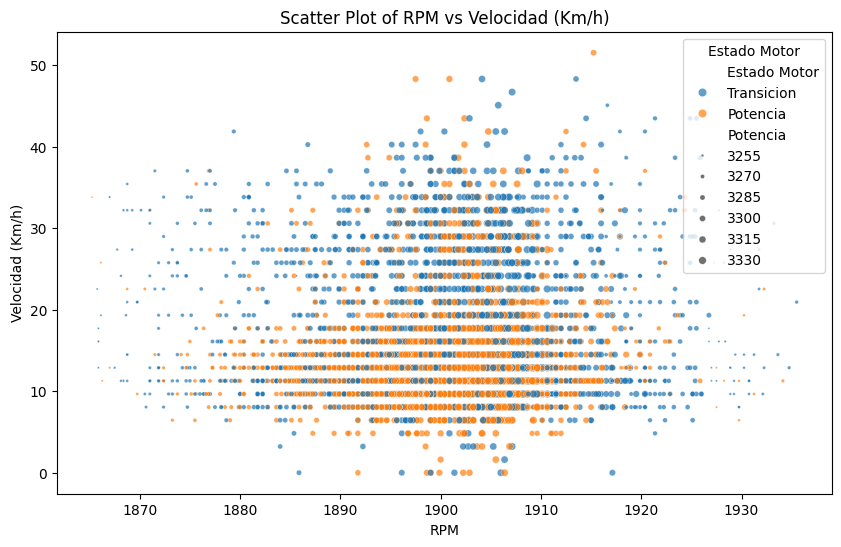

In [ ]:
x_col = 'RPM'
y_col = 'Velocidad (Km/h)'
size_col = 'Potencia'
hue_col = 'Estado Motor'

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x=x_col, y=y_col, hue=hue_col, size=size_col, sizes=(2, 30), alpha=0.7)
plt.title(f'Scatter Plot of {x_col} vs {y_col}')
plt.xlabel(x_col)
plt.ylabel(y_col)
plt.legend(title=hue_col)
plt.show()


Time Span : 2025-08-23 23:20:34 to 2025-08-25 06:41:41
Number of hours: 31.351944444444445
Number of records per hour: 1.5947974164281853


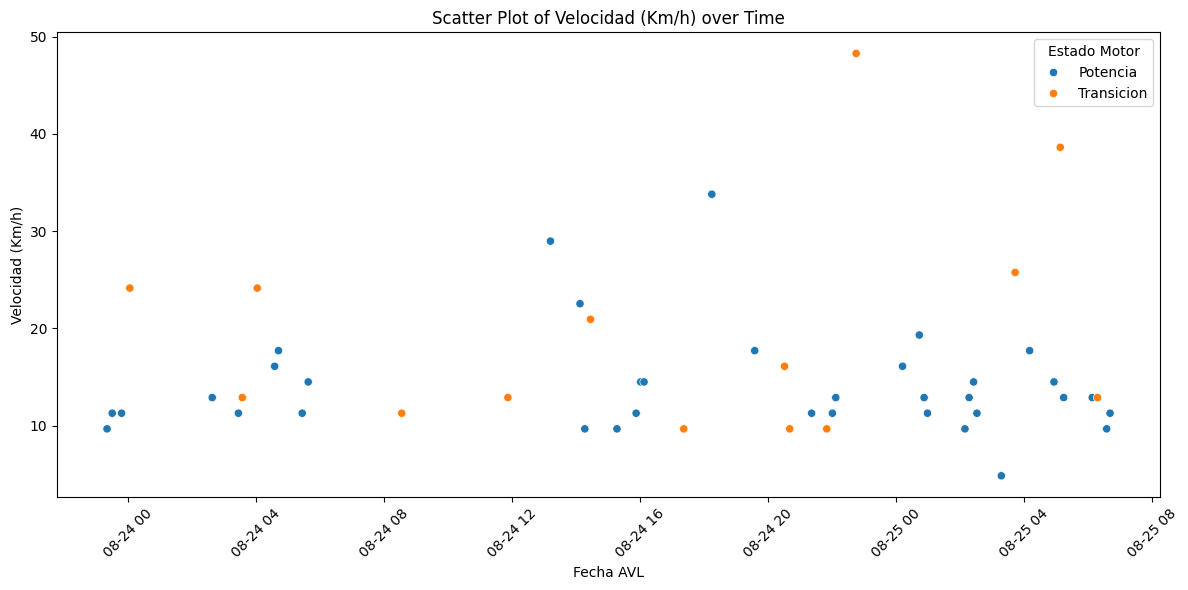

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

col = 'Velocidad (Km/h)'
hue_col = 'Estado Motor'
i=7
l_i = 50
df_aux = df.iloc[int(i*l_i):int(i*l_i+l_i)].copy()
df_aux.reset_index(inplace=True)
print(f'Time Span : {df_aux["Fecha AVL"].min()} to {df_aux["Fecha AVL"].max()}')
print(f'Number of hours: {(df_aux["Fecha AVL"].max() - df_aux["Fecha AVL"].min()).total_seconds() / 3600}')
print(f'Number of records per hour: {len(df_aux) / ((df_aux["Fecha AVL"].max() - df_aux["Fecha AVL"].min()).total_seconds() / 3600)}')
# Scatter PLot x=Fecha AVL, y=Actual Speed (RPM)
plt.figure(figsize=(12, 6))
sns.scatterplot(x='Fecha AVL', y=col, hue=hue_col, data=df_aux)
plt.title(f'Scatter Plot of {col} over Time')
plt.xlabel('Fecha AVL')
plt.ylabel(col)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
df_aux.iloc[3:5]

,Fecha AVL,Faena,Flota,ESN,AVL,Vehículo,Fecha Servidor,RPM,Pedal,F. de Carga,...,Engine Oil Priming Pump Control (bit),Engine Controlled Shutdown Request (bit),Engine Emergency (Immediate) Shutdown Indication (bit),Power (HP),SCR Thermal Management Active (bit),Engine Oil Filter Differential Pressure (Extended Range) (MCRS) (kPa),Latitud,Longitud,Velocidad (Km/h),Altitude (m)
3,2025-08-24 00:03:14,Las Bambas,'930E-4SE',66305887,103155,EX HT-007,2025-08-24 00:03:16,1901.375,100.0,100,...,3,3,3,3313.49,3,40,-14.06322,-72.30433,24.1402,4196
4,2025-08-24 02:37:50,Las Bambas,'930E-4SE',66305887,103155,EX HT-007,2025-08-24 02:37:52,1900.375,100.0,100,...,3,3,3,3311.74,3,20,-14.09283,-72.29901,12.8748,3869


In [ ]:
df.loc[:, 'delta_avl'] = df['Date_avl'].diff()
print(f'Percentile analysis')
print(df['delta_avl'].describe(percentiles=[0.05, 0.1, 0.2, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))

Percentile analysis
count                        10013
mean     0 days 01:02:54.379806251
std      0 days 02:09:07.476797988
min                0 days 00:00:07
5%                 0 days 00:01:40
10%                0 days 00:06:10
20%                0 days 00:31:52
25%                0 days 00:36:55
50%                0 days 00:52:00
75%                0 days 01:05:00
90%         0 days 01:24:41.800000
95%      0 days 01:52:53.999999999
99%      0 days 07:11:32.519999999
max                3 days 13:58:46
Name: delta_avl, dtype: object


In [ ]:
df_aux

,Fecha,Unit,Estado,EstadoMaquina,EstadoCarga,GPSLat,GPSLon,GPSElevation,CnkcasePres,DiffLubePres,...,RtFBrkTemp,RtLtExhTemp,RtRBrkTemp,StrgOilTemp,TCOutTemp,TrnLubeTemp,created_by_reindex,imputed_any,n_imputed_signals,time_gap_min
0,2025-01-01 00:02:00,T_10,ND,ND,Sin Carga,-30.254324,-71.091386,998.488372,0.151770,NaN,...,80.000000,-6.723517,78.833333,68.000000,80.739394,86.555556,0,0,0,NaN
1,2025-01-01 00:03:00,T_10,ND,ND,Sin Carga,-30.254331,-71.091389,996.500000,0.138828,NaN,...,79.750000,-7.042637,78.875000,68.000000,80.554545,86.416667,0,0,0,1.0
2,2025-01-01 00:04:00,T_10,None,ND,Sin Carga,-30.254292,-71.091454,997.133591,0.111046,NaN,...,79.333333,-6.907596,78.559524,67.309524,80.566722,86.045139,1,1,20,1.0
3,2025-01-01 00:05:00,T_10,None,ND,Sin Carga,-30.254252,-71.091520,997.767182,0.083264,NaN,...,78.916667,-6.772554,78.244048,66.619048,80.578899,85.673611,1,1,20,1.0
4,2025-01-01 00:06:00,T_10,None,ND,Sin Carga,-30.254213,-71.091585,998.400773,0.055482,NaN,...,78.500000,-6.637512,77.928571,65.928571,80.591076,85.302083,1,1,20,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6181645,2026-01-30 23:56:00,T_9,Operacional,Operacional Alto,Sin Carga,-30.254518,-71.096484,1023.049999,0.107313,131.404679,...,92.125000,0.853685,87.583333,67.350000,91.130556,90.819444,0,1,1,1.0
6181646,2026-01-30 23:57:00,T_9,Operacional,Operacional Alto,Sin Carga,-30.250783,-71.099808,1050.487712,0.091365,143.147552,...,90.125000,-1.506277,86.033333,67.350000,89.305556,90.708333,0,0,0,1.0
6181647,2026-01-30 23:58:00,T_9,Ralenti,Ralenti Alto,Sin Carga,-30.246659,-71.101252,1052.864915,0.069494,139.727043,...,88.100000,3.647761,86.700000,67.100000,88.108333,90.733333,0,0,0,1.0
6181648,2026-01-30 23:59:00,T_9,Ralenti,Ralenti Alto,Sin Carga,-30.247095,-71.100186,1004.574576,0.073976,141.599384,...,86.975000,6.820558,88.039286,66.891667,88.096970,90.770690,0,0,0,1.0


In [ ]:
[f.split('_') for f in os.listdir("../data/telemetry/golden/cda/reconstructions")]

[['CAT 789C', 'Direccion.parquet'],
 ['CAT 789C', 'Frenos.parquet'],
 ['CAT 789C', 'Motor.parquet'],
 ['CAT 789C', 'Tren de fuerza.parquet'],
 ['CAT 789D', 'Direccion.parquet'],
 ['CAT 789D', 'Frenos.parquet'],
 ['CAT 789D', 'Motor.parquet'],
 ['CAT 789D', 'Tren de fuerza.parquet']]

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

In [19]:
df_rec= pd.read_parquet("../data/telemetry/golden/cda/reconstructions/CAT 789C_Motor.parquet")
df_rec.truck_model.value_counts()

truck_model
CAT 789C    4474860
Name: count, dtype: int64

In [4]:
df_aux= pd.read_parquet("../data/telemetry/silver/cda/processed_data.parquet")

df_aux = df_aux[(df_aux.Unit=='T_11')].copy()
df_aux.set_index('Fecha', inplace=True)

df_aux.head()

,Unit,Estado,EstadoMaquina,EstadoCarga,GPSLat,GPSLon,GPSElevation,CnkcasePres,DiffLubePres,DiffTemp,...,RtFBrkTemp,RtLtExhTemp,RtRBrkTemp,StrgOilTemp,TCOutTemp,TrnLubeTemp,created_by_reindex,imputed_any,n_imputed_signals,time_gap_min
Fecha,,,,,,,,,,,,,,,,,,,,,
2025-01-01 00:02:00,T_11,Operacional,Operacional Bajo,Cargado,-30.244424,-71.095528,900.636957,0.128261,NaN,76.193182,...,93.833333,-4.365632,87.166667,68.500000,92.096296,87.500000,0,0,0,NaN
2025-01-01 00:03:00,T_11,Operacional,Operacional Bajo,Cargado,-30.244422,-71.095514,901.989796,0.119344,NaN,75.262533,...,92.750000,-4.902429,86.750000,69.125000,91.179365,87.245000,0,0,0,1.0
2025-01-01 00:04:00,T_11,Operacional,Operacional Bajo,Sobrecarga,-30.244429,-71.095525,901.186792,0.096065,NaN,73.244676,...,91.000000,-6.127813,85.875000,70.083333,89.679365,86.745000,0,0,0,1.0
2025-01-01 00:05:00,T_11,Operacional,ND,Sobrecarga,-30.244487,-71.094535,899.139583,0.090351,NaN,73.690278,...,89.625000,-5.599241,85.375000,70.583333,88.635714,86.495000,0,0,0,1.0
2025-01-01 00:06:00,T_11,Operacional,ND,Sobrecarga,-30.244619,-71.092790,904.245098,0.063267,NaN,75.201642,...,88.625000,-4.669220,84.875000,70.750000,87.776099,86.418913,0,0,0,1.0


=== Peru ===
Time Span : 2025-01-01 00:02:00 to 2026-01-10 00:31:00
Number of hours: 8976.5
Number of records: 538590
Number of records per hour: 60.0
Percentile analysis of time differences
   min  10%  25%  50%  75%  90%  max
0  1.0  1.0  1.0  1.0  1.0  1.0  1.0


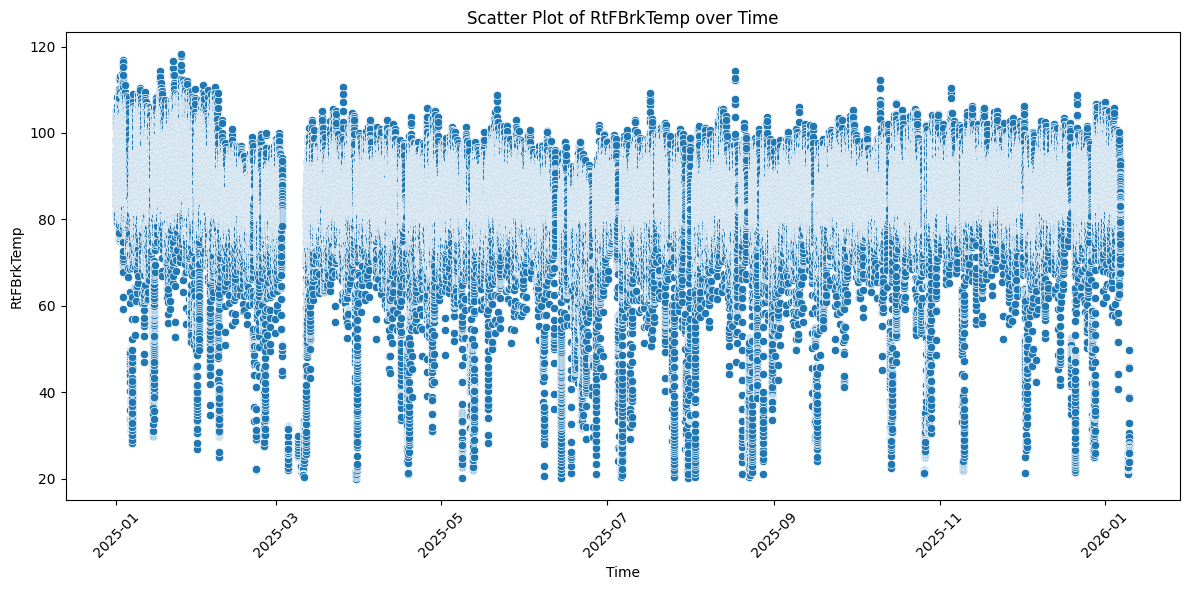

In [5]:
from typing import Optional
# df_aux = df_rec[df_rec.Unit=='T_11'].copy()
df_aux.loc[:, 'delta_avl'] = df_aux.index.to_series().diff()

def plot_signal_over_time(df: pd.DataFrame, signal_col: str, hue_col: Optional[str] = None, country_name: Optional[str] = None):
    print(f'=== {country_name} ===')
    print(f'Time Span : {df.index.min()} to {df.index.max()}')
    print(f'Number of hours: {(df.index.max() - df.index.min()).total_seconds() / 3600:.1f}')
    print(f'Number of records: {len(df)}')
    print(f'Number of records per hour: {len(df) / ((df.index.max() - df.index.min()).total_seconds() / 3600):.1f}')
    df_aux = df.index.to_series().diff()
    df_aux = df_aux.dt.total_seconds() / 60  # to minutes
    print(f'Percentile analysis of time differences')
    print(pd.DataFrame(df_aux.describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9])).T.iloc[:,3:].reset_index(drop=True))
    plt.figure(figsize=(12, 6))
    sns.scatterplot(x=df.index, y=signal_col, hue=hue_col, data=df)
    plt.title(f'Scatter Plot of {signal_col} over Time')
    plt.xlabel('Time')
    plt.ylabel(signal_col)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    
plot_signal_over_time(df_aux, 'RtFBrkTemp', hue_col=None, country_name='Peru')


In [6]:
df_health_index = pd.read_parquet("../data/telemetry/golden/cda/health_index.parquet")
df_health_index.loc[:, 'evaluation_weekyear'] = df_health_index['start_time'].dt.to_period('W').apply(lambda r: r.start_time)

df_health_index.loc[:, 'hi_aux'] = df_health_index['health_index'].round(1)
df_health_index.sort_values(by=['hi_aux'], inplace=True)

df_health_index.head()

,Unit,start_time,end_time,health_index,reconstruction_error_score,component,truck_model,created_fraction,imputed_fraction,evaluation_weekyear,hi_aux
235664,T_11,2025-04-12 18:02:00,2025-04-12 19:01:00,0.010065,4.598655,Direccion,CAT 789C,0.633333,0.000000,2025-04-07,0.0
286311,T_16,2025-10-16 17:34:00,2025-10-16 18:33:00,0.005671,5.172390,Direccion,CAT 789C,0.000000,0.266667,2025-10-13,0.0
265305,T_14,2025-07-22 23:02:00,2025-07-23 00:01:00,0.024355,3.715032,Direccion,CAT 789C,0.300000,0.316667,2025-07-21,0.0
287315,T_16,2025-11-27 13:34:00,2025-11-27 14:33:00,0.032274,3.433507,Direccion,CAT 789C,0.916667,0.166667,2025-11-24,0.0
287314,T_16,2025-11-27 12:34:00,2025-11-27 13:33:00,0.027028,3.610878,Direccion,CAT 789C,0.883333,0.266667,2025-11-24,0.0


Example Unit: T_11
Start Time: 2025-11-06 06:02:00
End Time: 2025-11-06 07:01:00
Component: Motor


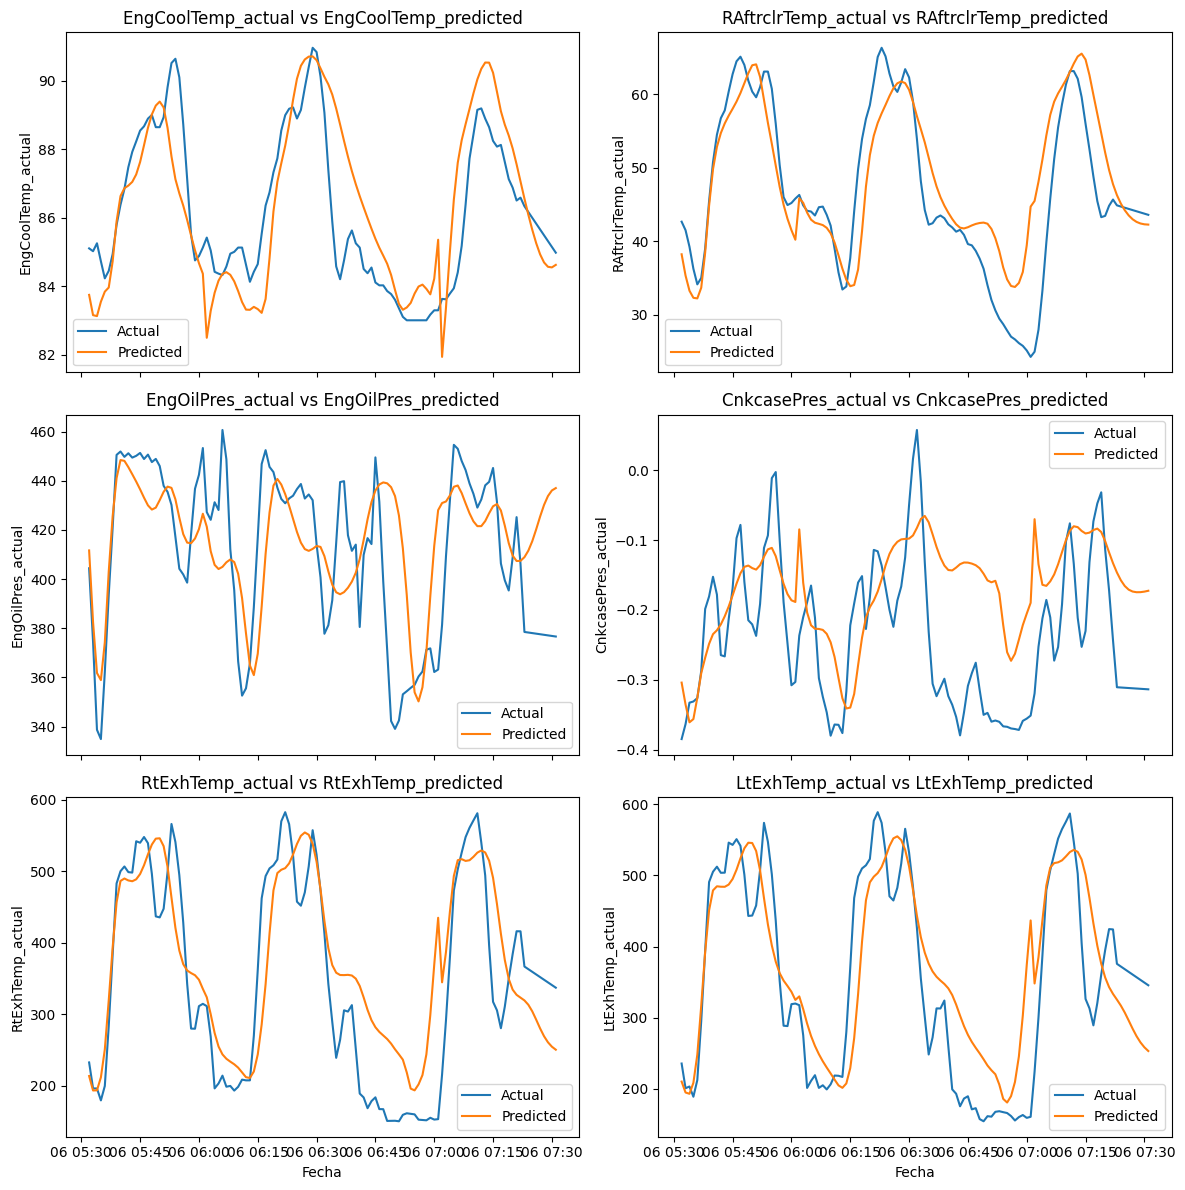

In [45]:
import numpy as np

df_aux = df_health_index[
        (df_health_index['hi_aux'] == 0.8)
        & (df_health_index['truck_model'] == 'CAT 789C')
        & (df_health_index['component'] == 'Motor')
        ]

s = np.random.choice(df_aux.index, size=1, replace=False)
s = s[0]
unit_aux = df_aux.Unit.loc[s]
start_time_aux = df_aux.start_time.loc[s]
end_time_aux = df_aux.end_time.loc[s]
component_aux = df_aux.component.loc[s]

example_rec = df_rec[
        (df_rec.Unit == unit_aux)
        & (df_rec.Fecha >= start_time_aux - pd.Timedelta(hours = 0.5))
        & (df_rec.Fecha <= end_time_aux + pd.Timedelta(hours = 0.5))
        & (df_rec.component == component_aux)
]

print(f'Example Unit: {unit_aux}'
      f'\nStart Time: {start_time_aux}'
      f'\nEnd Time: {end_time_aux}'
      f'\nComponent: {component_aux}')

plot_timeseries(example_rec)

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt
# d_index = {
#     float(i) : df_health_index[
#         (df_health_index['hi_aux'] == i)
#         & (df_health_index['truck_model'] == 'CAT 789C')
#         & (df_health_index['component'] == 'Motor')
#         ].sort_values(by='imputed_fraction', ascending=False).iloc[0] for i in df_health_index['hi_aux'].unique()
# }

# d_rec = {
#     float(i) : df_rec[
#         (df_rec['Fecha'] >= d_index[i]['start_time'])
#         & (df_rec['Fecha'] <= d_index[i]['end_time'])
#         & (df_rec['Unit'] == d_index[i]['Unit'])
#     ]
#     for i in d_index.keys()
# }

def plot_timeseries(df_in, ):
    '''
    Using seaborn and matplotlib we use the reconstruction data to plot the timeseries of the component.
    We isolate the signals of the component and plot {feature}_actual vs {feature}_predicted, where feature is in the list of features of the component. 
    The x-axis is always the timestamp (colname: Fecha), and the y-axis is the value of the feature (we must create subplots for each feature - sharex=True). 
    '''
    features = [col for col in df_in.columns if ('_actual' in col or '_predicted' in col)]
    n_features = len(features) // 2
    fig, axes = plt.subplots(n_features//2, 2, figsize=(12, 2*n_features), sharex=True)
    k, j = 0, 0
    for i, feature in enumerate(features):
        if '_actual' in feature:
            feature_reconstruction = feature.replace('_actual', '_predicted')
            sns.lineplot(x='Fecha', y=feature, data=df_in, ax=axes[k, j], label='Actual')
            sns.lineplot(x='Fecha', y=feature_reconstruction, data=df_in, ax=axes[k, j], label='Predicted')
            axes[k, j].set_title(f'{feature} vs {feature_reconstruction}')
            axes[k, j].legend()
            j += 1
            if j == 2:
                j = 0
                k += 1
    plt.xlabel('Fecha')
    plt.tight_layout()
    plt.show()

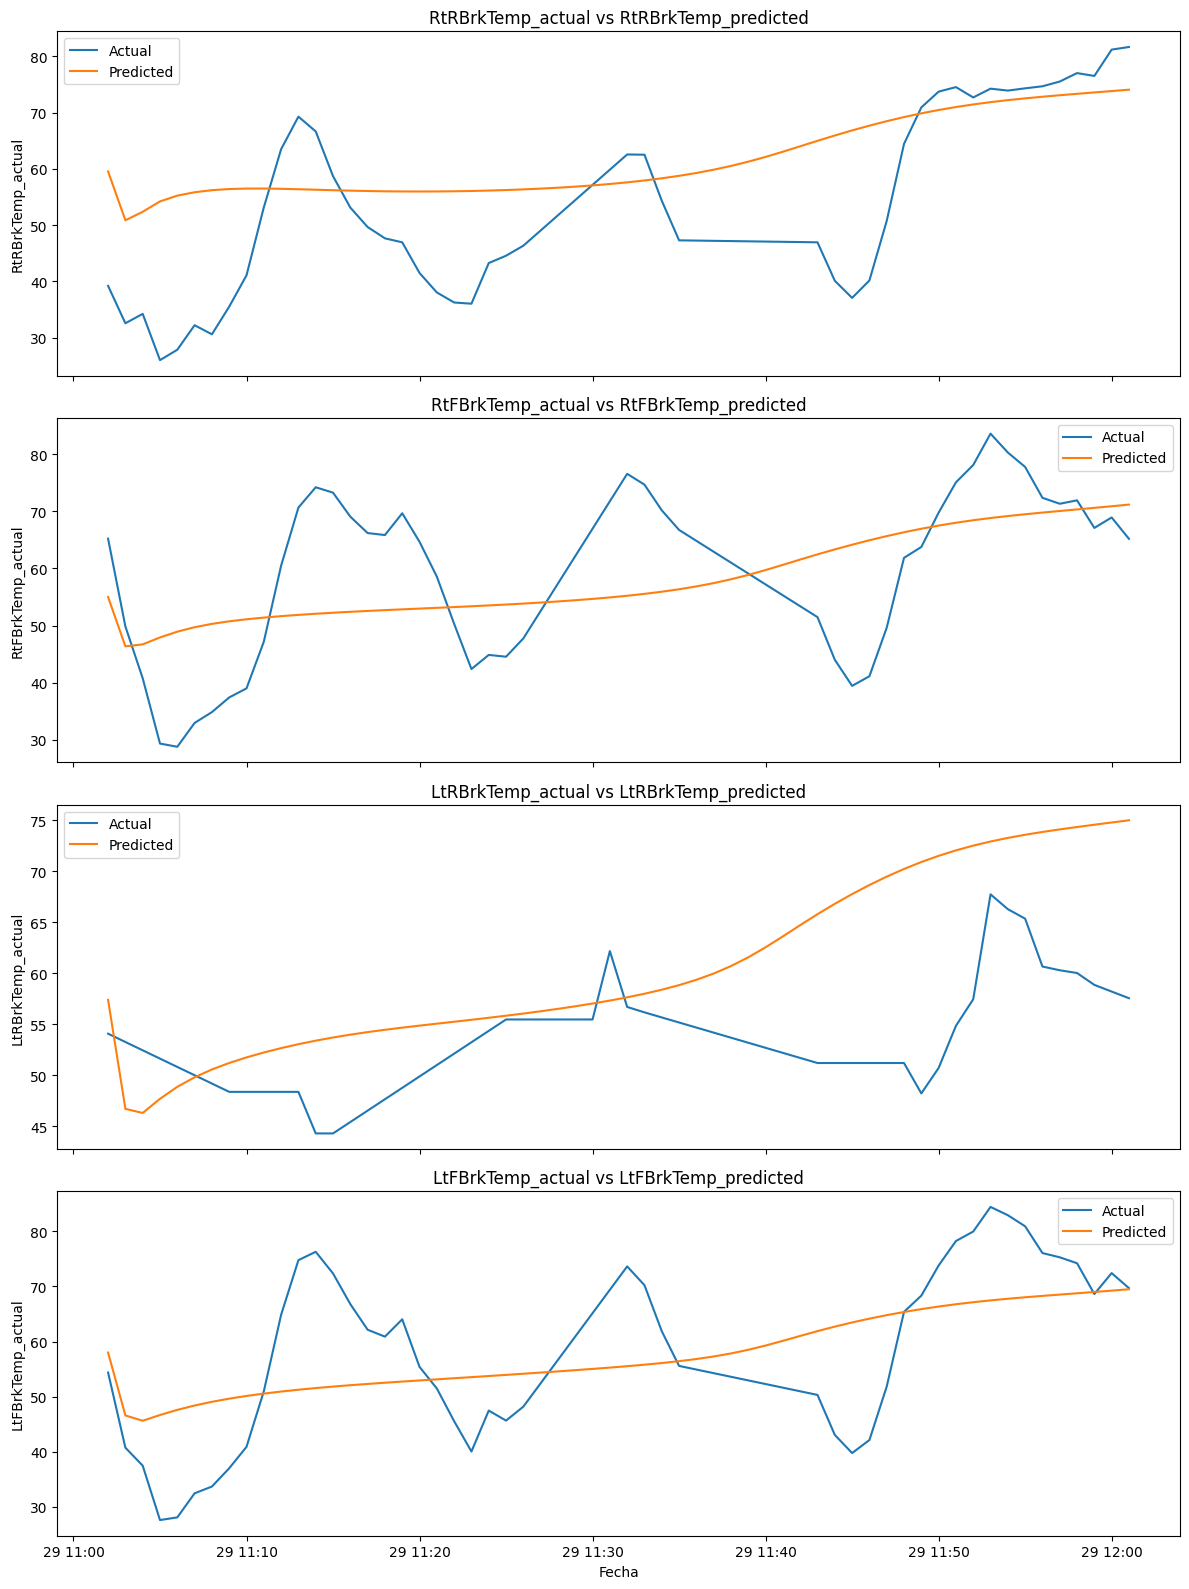

In [13]:
plot_timeseries(d_rec[0.4])
# plot_timeseries(df_rec[-60*24*7:])

In [9]:
d_index

{0.0: Unit                                         T_15
 start_time                    2025-09-21 15:02:00
 end_time                      2025-09-21 16:01:00
 health_index                             0.030573
 reconstruction_error_score               3.487625
 component                                  Frenos
 truck_model                              CAT 789C
 created_fraction                              0.0
 imputed_fraction                             0.85
 evaluation_weekyear           2025-09-15 00:00:00
 hi_aux                                        0.0
 Name: 201656, dtype: object,
 0.1: Unit                                         T_15
 start_time                    2025-10-30 00:02:00
 end_time                      2025-10-30 01:01:00
 health_index                             0.090507
 reconstruction_error_score               2.402326
 component                                  Frenos
 truck_model                              CAT 789C
 created_fraction                         